In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('data/drom_archive_cleaned_2018-2025.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Год              1000000 non-null  float64
 1   Цена             1000000 non-null  float64
 2   Объем двигателя  1000000 non-null  float64
 3   Тип двигателя    1000000 non-null  str    
 4   Мощность         1000000 non-null  float64
 5   Коробка передач  1000000 non-null  str    
 6   Привод           1000000 non-null  str    
 7   Пробег           1000000 non-null  float64
 8   Поколение        1000000 non-null  float64
 9   Тип кузова       1000000 non-null  str    
 10  Метка            1000000 non-null  str    
 11  Город            1000000 non-null  str    
 12  Год объявления   1000000 non-null  int64  
 13  Возраст авто     1000000 non-null  float64
 14  Модель           1000000 non-null  str    
dtypes: float64(7), int64(1), str(7)
memory usage: 114.4 MB


In [5]:
categorical = ['Тип двигателя', 'Коробка передач', 'Модель', 'Привод', 'Тип кузова', 'Метка', 'Город']
numerical = ['Год', 'Объем двигателя', 'Мощность', 'Пробег', 'Год объявления', 'Возраст авто', 'Поколение']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numerical)], remainder='drop')
lr_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])

In [6]:
y = df['Цена']
X = df.drop('Цена', axis=1)

df['price_stratum'] = pd.qcut(df['Цена'], q=10, labels=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['price_stratum'])

In [7]:
lr_model.fit(X_train, y_train)
joblib.dump(lr_model, "models/lr_model.pkl")

['models/lr_model.pkl']

In [8]:
def pred_metrics(model, X_test, y_test, model_name, file_name):
    y_pred = model.predict(X_test) # предсказания на тестовой выборке
    metrics = { # словарь с метриками
        "model_name": model_name,
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred)
    }
    # сохранение в pickle-файл
    with open(f"metrics/{file_name}_metrics.pkl", "wb") as f:
        pickle.dump(metrics, f)

    return metrics

In [9]:
print(pred_metrics(lr_model, X_test, y_test, 'Linear Regression', 'lr'))

{'model_name': 'Linear Regression', 'MSE': 106867539134.21931, 'RMSE': np.float64(326906.00963307376), 'MAE': 240728.92600700917, 'R2': 0.6379564493090737, 'MAPE': 0.2528917608399021}


In [10]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=80, # количество деревьев
        random_state=42,
        n_jobs=-1, # задействует все ядра процессора
        max_depth=20, # максимальное количество уровней
        min_samples_split=50,
        verbose=2 # отображает процесс обучения
    ))
])

In [11]:
rf_model.fit(X_train, y_train)
joblib.dump(rf_model, "models/rf_model.pkl")

['models/rf_model.pkl']

In [12]:
print(pred_metrics(rf_model, X_test, y_test, 'Random Forest', 'rf'))

[Parallel(n_jobs=6)]: Done  80 out of  80 | elapsed:    0.7s finished


In [13]:
categorical_target = ['Город', 'Модель', 'Метка']      # Target Encoding
categorical_onehot = ['Тип двигателя', 'Коробка передач', 'Привод', 'Тип кузова']  # OneHot

preprocessor = ColumnTransformer(
    transformers=[
        ('target', TargetEncoder(), categorical_target),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_onehot),
        ('num', 'passthrough', numerical)
    ]
)

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=2000, # количество деревьев
        n_jobs=-1, # задействует все ядра
        random_state=42,
        eval_metric='rmse' # метрика для обучения
    ))
])

In [14]:
xgb_model.fit(X_train, y_train, regressor__verbose=True)
joblib.dump(xgb_model, "models/xgb_model.pkl")

['models/xgb_model.pkl']

In [15]:
print(pred_metrics(xgb_model, X_test, y_test, 'XGBoost', 'xgb'))

{'model_name': 'XGBoost', 'MSE': 26745515469.34227, 'RMSE': np.float64(163540.56215307035), 'MAE': 106620.03601125, 'R2': 0.9093921179057146, 'MAPE': 0.10412062984194978}


In [16]:
pd.options.display.float_format = '{:_.2f}'.format
files = ["metrics/lr_metrics.pkl", "metrics/rf_metrics.pkl", "metrics/xgb_metrics.pkl"]

all_metrics = []

for file in files:
    with open(file, "rb") as f:
        all_metrics.append(pickle.load(f))

df = pd.DataFrame(all_metrics)
df

,model_name,MSE,RMSE,MAE,R2,MAPE
0,Linear Regression,106_867_539_134.22,326_906.01,240_728.93,0.64,0.25
1,Random Forest,30_842_026_873.66,175_618.98,116_367.68,0.90,0.11
2,XGBoost,26_745_515_469.34,163_540.56,106_620.04,0.91,0.10


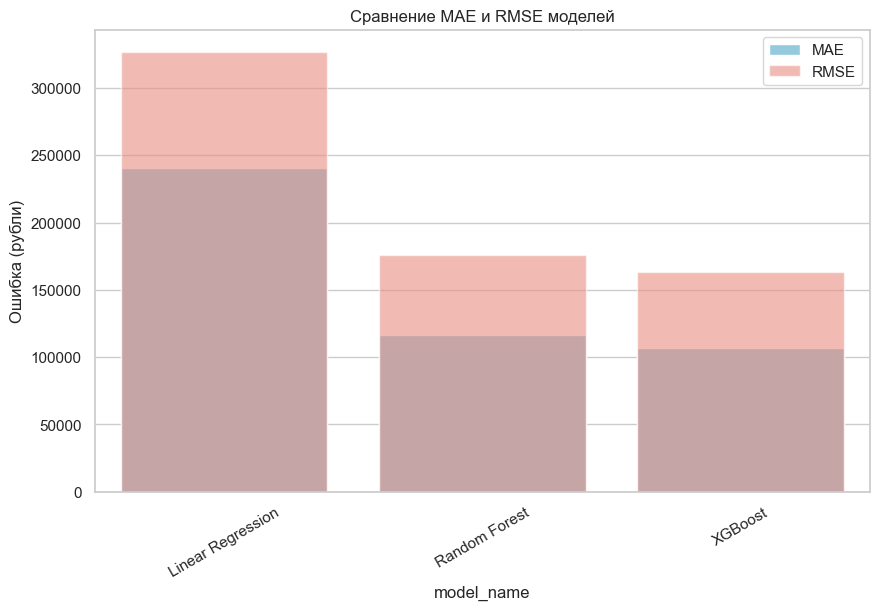

In [17]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.barplot(x="model_name", y="MAE", data=df, color="skyblue", label="MAE")
sns.barplot(x="model_name", y="RMSE", data=df, color="salmon", label="RMSE", alpha=0.6)
plt.ylabel("Ошибка (рубли)")
plt.xticks(rotation=30)
plt.title("Сравнение MAE и RMSE моделей")
plt.legend()

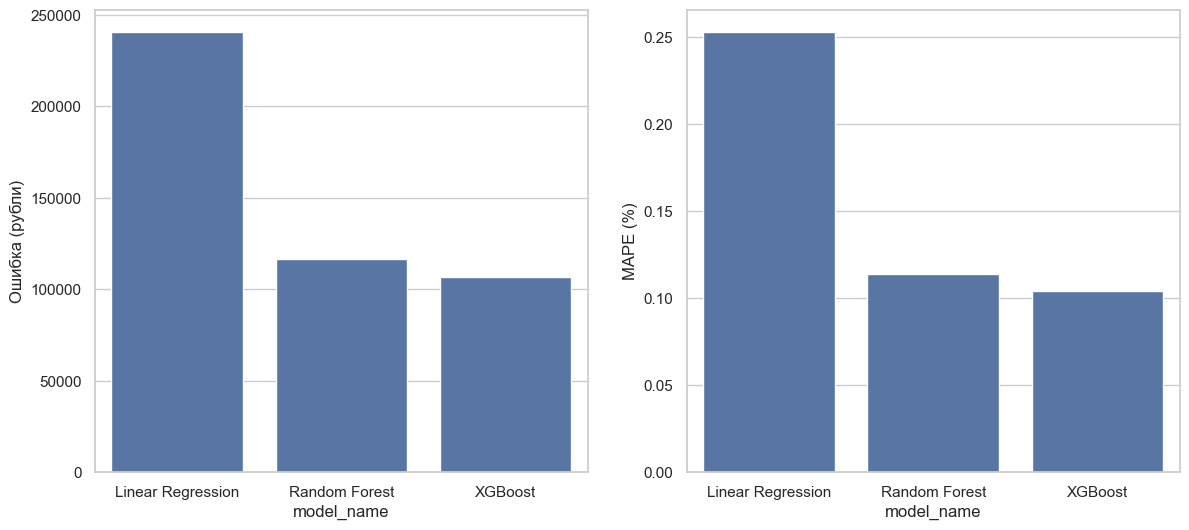

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x="model_name", y="MAE", data=df, ax=axes[0])
axes[0].set_ylabel("Ошибка (рубли)")

sns.barplot(x="model_name", y="MAPE", data=df, ax=axes[1])
axes[1].set_ylabel("MAPE (%)")

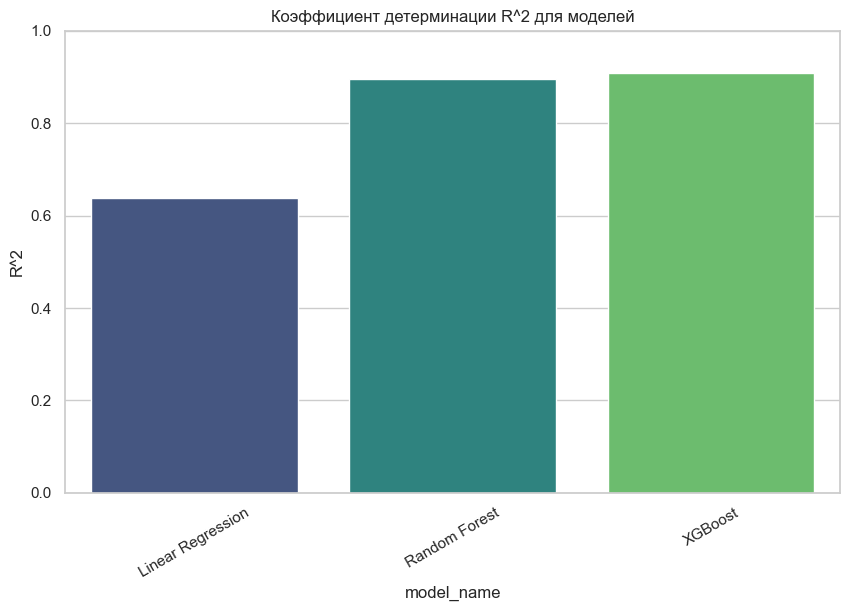

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x="model_name", y="R2", data=df, palette="viridis")
plt.ylabel("R^2")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.title("Коэффициент детерминации R^2 для моделей")